In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# -------------------------------
# 1. Load the data
# -------------------------------
df = pd.read_csv("/content/Diwali Sales Data.csv", encoding='latin1')
df.head()



,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [ ]:
# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)


Dataset shape: (11251, 15)

First 5 rows:
   User_ID  Cust_name Product_ID Gender Age Group  Age  Marital_Status  \
0  1002903  Sanskriti  P00125942      F     26-35   28               0   
1  1000732     Kartik  P00110942      F     26-35   35               1   
2  1001990      Bindu  P00118542      F     26-35   35               1   
3  1001425     Sudevi  P00237842      M      0-17   16               0   
4  1000588       Joni  P00057942      M     26-35   28               1   

            State      Zone       Occupation Product_Category  Orders  \
0     Maharashtra   Western       Healthcare             Auto       1   
1  Andhra Pradesh  Southern             Govt             Auto       3   
2   Uttar Pradesh   Central       Automobile             Auto       3   
3       Karnataka  Southern     Construction             Auto       2   
4         Gujarat   Western  Food Processing             Auto       2   

    Amount  Status  unnamed1  
0  23952.0     NaN       NaN  
1  23934.0  

In [ ]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64


In [ ]:
# Drop completely empty columns
df.drop(columns=['Status', 'unnamed1'], inplace=True, errors='ignore')
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [ ]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [ ]:
# Drop rows where 'Amount' is missing (critical for sales analysis)
# Also check if 'Amount' column exists; if not, we keep all.
if 'Amount' in df.columns:
    initial_len = len(df)
    df.dropna(subset=['Amount'], inplace=True)
    print(f"Dropped {initial_len - len(df)} rows with missing Amount")

Dropped 12 rows with missing Amount


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Occupation        11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB


In [ ]:
# Ensure 'Amount' is numeric (some values may have commas, but here they seem decimal)
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
# Drop rows where conversion failed
df.dropna(subset=['Amount'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Occupation        11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB


In [ ]:
# Convert 'Orders' to integer (should be fine)
df['Orders'] = pd.to_numeric(df['Orders'], errors='coerce').fillna(0).astype(int)

# Check for duplicate rows (if any)
df.drop_duplicates(inplace=True)

In [ ]:
# Basic statistics after cleaning
print("\nAfter cleaning:")
print(df.info())
print("\nSummary statistics for Amount and Orders:")
print(df[['Amount', 'Orders']].describe())



After cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 11231 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11231 non-null  int64  
 1   Cust_name         11231 non-null  object 
 2   Product_ID        11231 non-null  object 
 3   Gender            11231 non-null  object 
 4   Age Group         11231 non-null  object 
 5   Age               11231 non-null  int64  
 6   Marital_Status    11231 non-null  int64  
 7   State             11231 non-null  object 
 8   Zone              11231 non-null  object 
 9   Occupation        11231 non-null  object 
 10  Product_Category  11231 non-null  object 
 11  Orders            11231 non-null  int64  
 12  Amount            11231 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB
None

Summary statistics for Amount and Orders:
             Amount        Orders
count  11231.000000  11231.000

# Exploratory Data Analysis & Visualizations


/tmp/ipykernel_10368/2420845540.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_sales.index, y=gender_sales.values, palette='viridis')


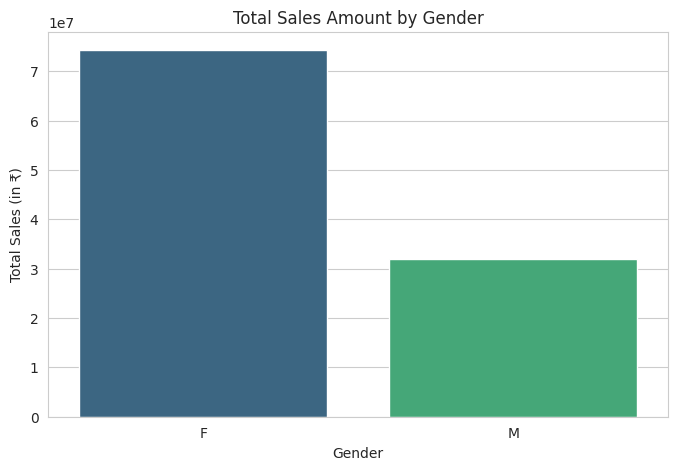

In [ ]:
# 3.1 Total sales by Gender
gender_sales = df.groupby('Gender')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=gender_sales.index, y=gender_sales.values, palette='viridis')
plt.title('Total Sales Amount by Gender')
plt.ylabel('Total Sales (in ₹)')
plt.xlabel('Gender')
plt.show()


/tmp/ipykernel_10368/951407842.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_orders.index, y=gender_orders.values, palette='magma')


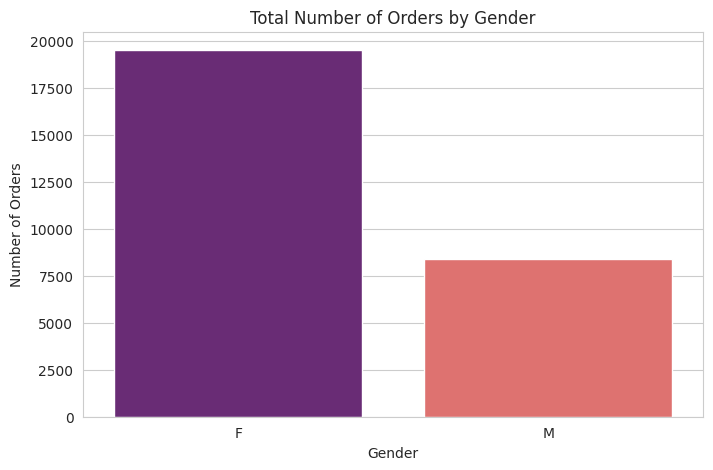

In [ ]:
# 3.2 Total orders by Gender (count of orders, not sum of order numbers)
gender_orders = df.groupby('Gender')['Orders'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=gender_orders.index, y=gender_orders.values, palette='magma')
plt.title('Total Number of Orders by Gender')
plt.ylabel('Number of Orders')
plt.xlabel('Gender')
plt.show()

/tmp/ipykernel_10368/1331086565.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_sales.index, y=age_sales.values, palette='coolwarm')


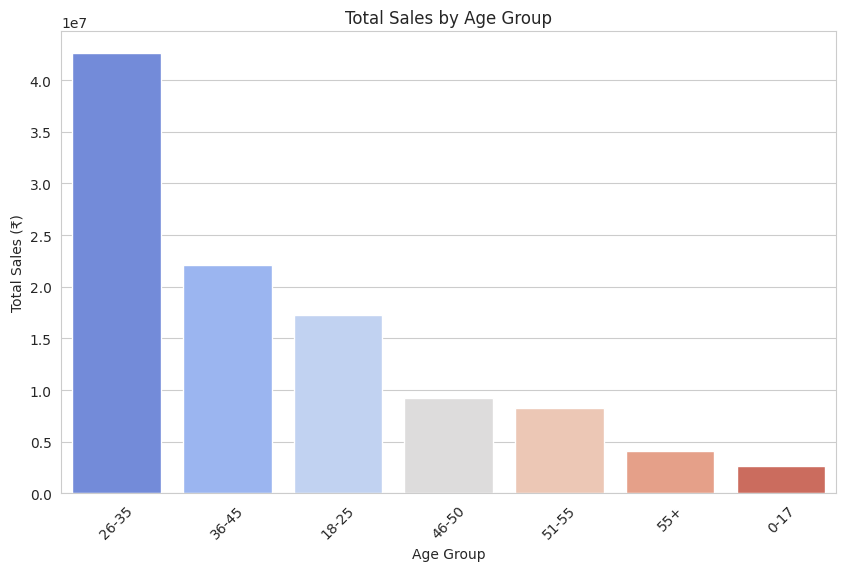

In [ ]:
# 3.3 Sales by Age Group
age_sales = df.groupby('Age Group')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=age_sales.index, y=age_sales.values, palette='coolwarm')
plt.title('Total Sales by Age Group')
plt.ylabel('Total Sales (₹)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_10368/406283968.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.index, y=state_sales.values, palette='Blues_d')


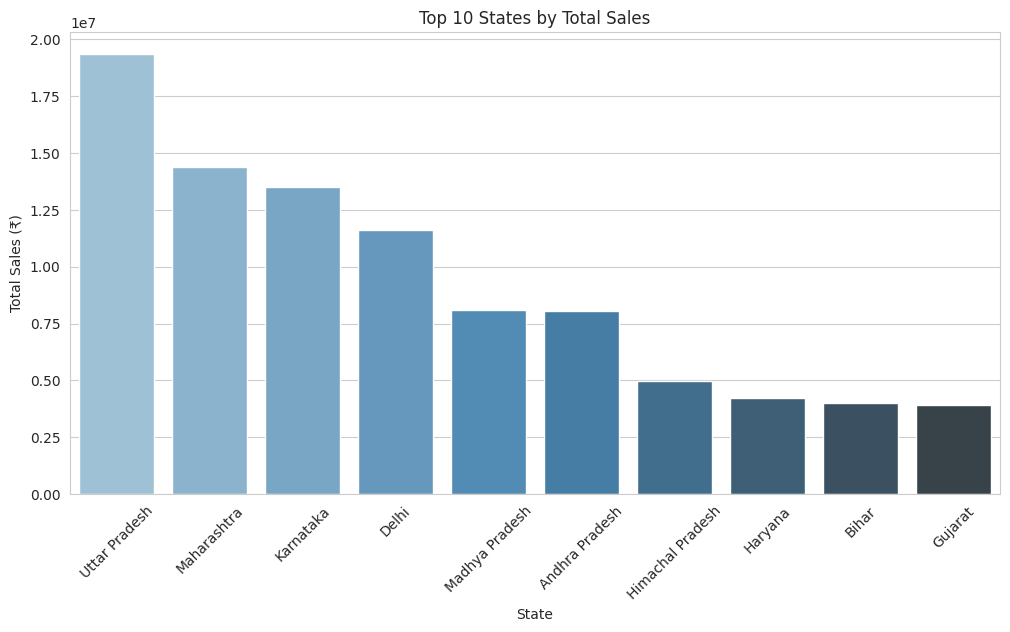

In [ ]:
# 3.4 Top 10 States by Sales
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=state_sales.index, y=state_sales.values, palette='Blues_d')
plt.title('Top 10 States by Total Sales')
plt.ylabel('Total Sales (₹)')
plt.xlabel('State')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_10368/762551641.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.values, y=cat_sales.index, palette='rocket')


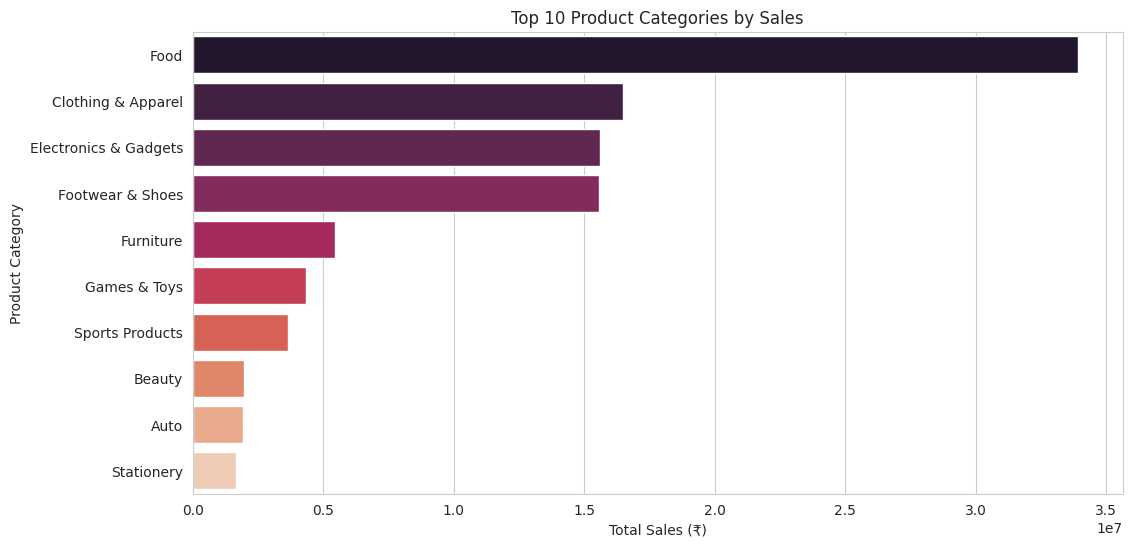

In [ ]:
# 3.5 Sales by Product Category (use Product_Category column)
cat_sales = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=cat_sales.values, y=cat_sales.index, palette='rocket')
plt.title('Top 10 Product Categories by Sales')
plt.xlabel('Total Sales (₹)')
plt.ylabel('Product Category')
plt.show()

/tmp/ipykernel_10368/1188724573.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_orders.values, y=cat_orders.index, palette='Spectral')


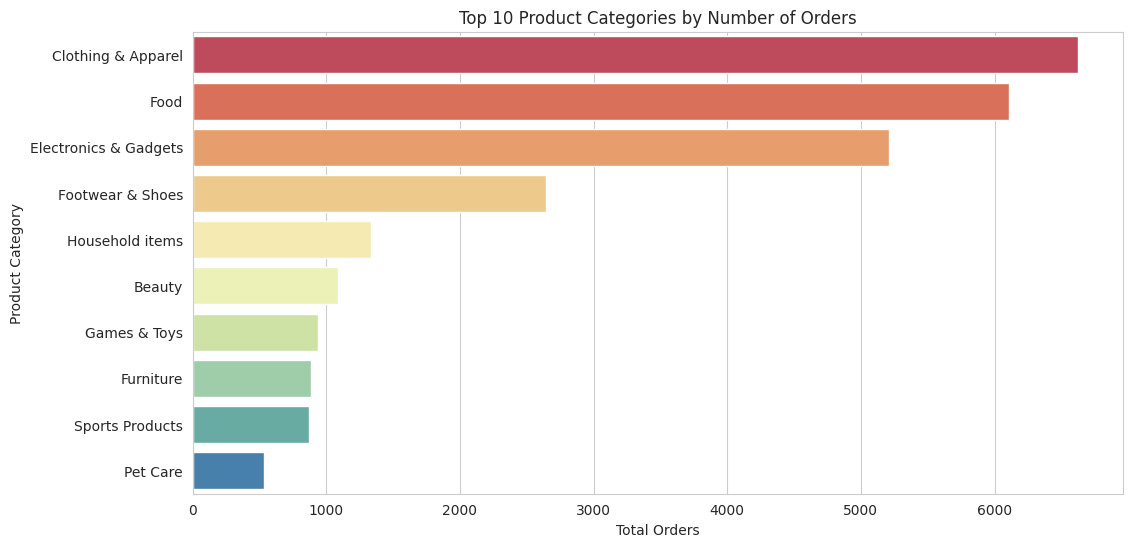

In [ ]:
# 3.6 Number of orders per Product Category
cat_orders = df.groupby('Product_Category')['Orders'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=cat_orders.values, y=cat_orders.index, palette='Spectral')
plt.title('Top 10 Product Categories by Number of Orders')
plt.xlabel('Total Orders')
plt.ylabel('Product Category')
plt.show()

/tmp/ipykernel_10368/888193568.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=occ_sales.values, y=occ_sales.index, palette='cubehelix')


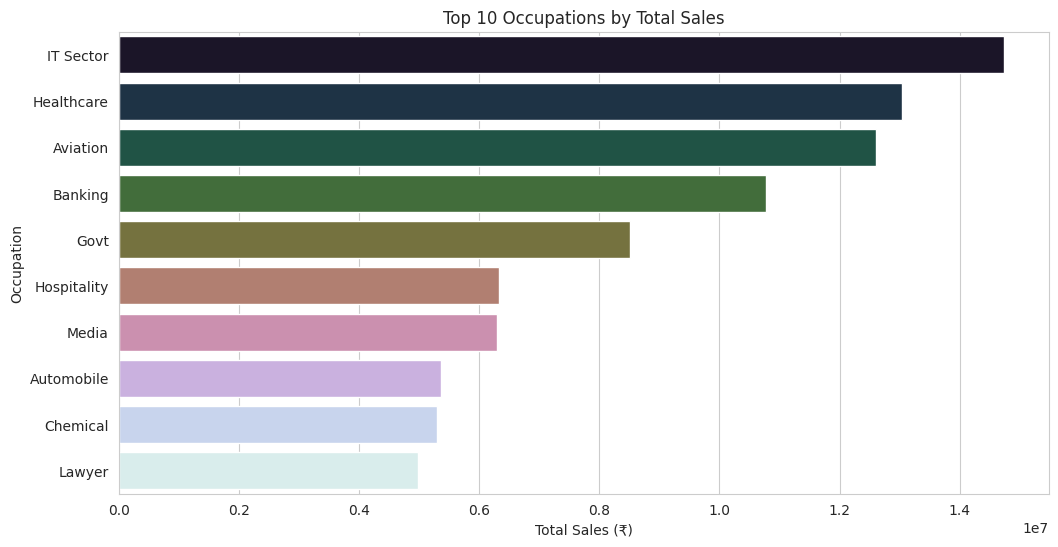

In [ ]:
# 3.7 Sales by Occupation
occ_sales = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=occ_sales.values, y=occ_sales.index, palette='cubehelix')
plt.title('Top 10 Occupations by Total Sales')
plt.xlabel('Total Sales (₹)')
plt.ylabel('Occupation')
plt.show()

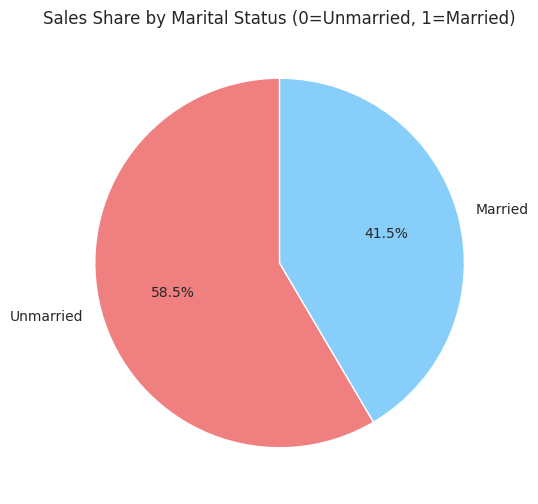

In [ ]:
# 3.8 Marital Status impact
marital_sales = df.groupby('Marital_Status')['Amount'].sum()
plt.figure(figsize=(6,6))
plt.pie(marital_sales, labels=['Unmarried', 'Married'], autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue'])
plt.title('Sales Share by Marital Status (0=Unmarried, 1=Married)')
plt.show()

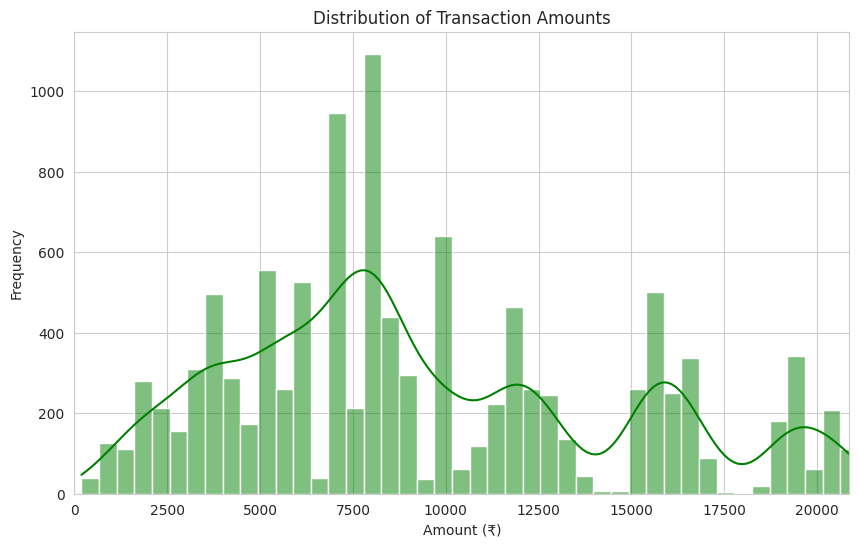

In [ ]:
# 3.9 Distribution of Amount spent (histogram)
plt.figure(figsize=(10,6))
sns.histplot(df['Amount'], bins=50, kde=True, color='green')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount (₹)')
plt.ylabel('Frequency')
plt.xlim(0, df['Amount'].quantile(0.99))  # zoom to 99th percentile
plt.show()


/tmp/ipykernel_10368/31873260.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_order.index, y=avg_order.values, palette='plasma')


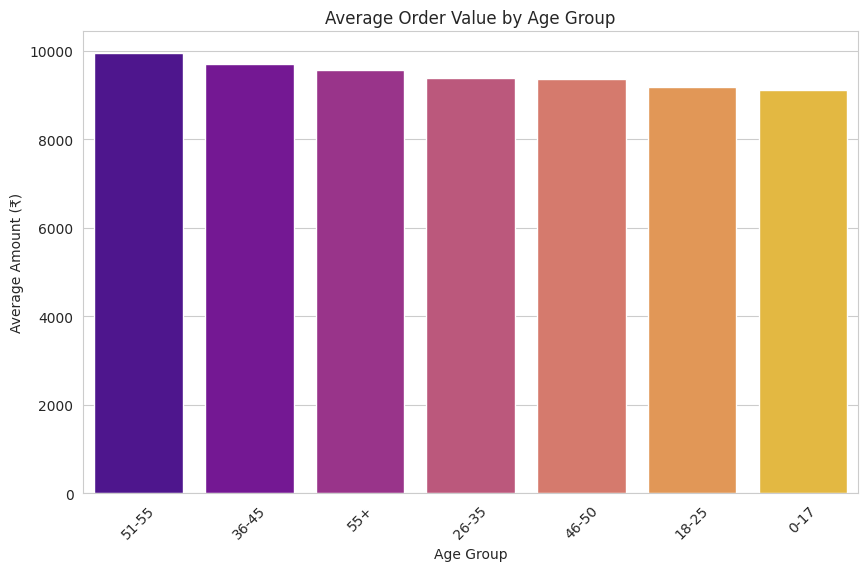

In [ ]:
# 3.10 Average order value by Age Group
avg_order = df.groupby('Age Group')['Amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=avg_order.index, y=avg_order.values, palette='plasma')
plt.title('Average Order Value by Age Group')
plt.ylabel('Average Amount (₹)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 4. Additional Insights (optional)
# -------------------------------
# Print total revenue and total orders
print(f"\nTotal Revenue: ₹{df['Amount'].sum():,.2f}")
print(f"Total Orders (sum of Order quantities): {df['Orders'].sum():,}")
print(f"Number of unique customers: {df['User_ID'].nunique()}")
print(f"Number of unique products sold: {df['Product_ID'].nunique()}")

# Save cleaned data for future use (optional)
df.to_csv('Diwali_Sales_Cleaned.csv', index=False)
print("\nCleaned data saved as 'Diwali_Sales_Cleaned.csv'")


Total Revenue: ₹106,178,828.43
Total Orders (sum of Order quantities): 27,955
Number of unique customers: 3752
Number of unique products sold: 2350

Cleaned data saved as 'Diwali_Sales_Cleaned.csv'
